In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

TYPES: 
* 	 1. Normalization and Standardization. 
*	 2. Scaling to Minimum and Maximum values.
*	 3. Scaling to Median and Quantiles.
*	 4. Gaussian Transformation:
	
    *	    Reciprocal Transformation.
    *    Square Root Transformation. 
	*    Exponential Transformation.
	 *   Box Cox Transformation.
	 *   Logarithmic Transformation.


* When to use Standardization and Normalization?: 
  * Standarization- we use when our data follow the Gaussian Distribution.
  * Normalization - we use when our data not follow the Gaussain Distribution.

### Standardization
* we try to bring all the features and variables in same scale. Standardization means centreing the variable at zero. 
* We try to scale down mean of 0, std = 1

In [4]:
data = pd.read_csv('train_titanic.csv', usecols = ['Pclass','Age','Fare','Survived'])

In [5]:
data.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [6]:
data.Age.fillna(data.Age.median(), inplace = True)

In [7]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
sc = scaler.fit_transform(data)

In [11]:
pd.DataFrame(sc)

,0,1,2,3
0,-0.789272,0.827377,-0.565736,-0.502445
1,1.266990,-1.566107,0.663861,0.786845
2,1.266990,0.827377,-0.258337,-0.488854
3,1.266990,-1.566107,0.433312,0.420730
4,-0.789272,0.827377,0.433312,-0.486337
...,...,...,...,...
886,-0.789272,-0.369365,-0.181487,-0.386671
887,1.266990,-1.566107,-0.796286,-0.044381
888,-0.789272,0.827377,-0.104637,-0.176263
889,1.266990,-1.566107,-0.258337,-0.044381


In [12]:
# fit for training 
# fit transform for transforming the data.

(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([-1.56610693, -1.44643272, -1.32675851, -1.2070843 , -1.08741009,
        -0.96773588, -0.84806167, -0.72838747, -0.60871326, -0.48903905,
        -0.36936484, -0.24969063, -0.13001642, -0.01034222,  0.10933199,
         0.2290062 ,  0.34868041,  0.46835462,  0.58802883,  0.70770304,
         0.82737724]),
 <BarContainer object of 20 artists>)

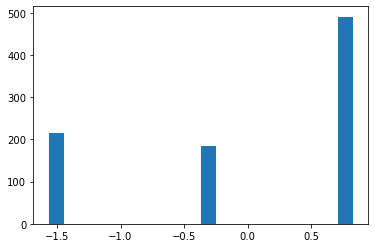

In [14]:
plt.hist(sc[:,1],bins = 20)

### Min Max Scaling
* It's scales the value between 0 to 1

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
min_max = MinMaxScaler()
df_min_max = pd.DataFrame(min_max.fit_transform(data), columns = data.columns)
    

In [19]:
df_min_max.head()

,Survived,Pclass,Age,Fare
0,0.0,1.0,0.271174,0.014151
1,1.0,0.0,0.472229,0.139136
2,1.0,1.0,0.321438,0.015469
3,1.0,0.0,0.434531,0.103644
4,0.0,1.0,0.434531,0.015713


### Robust Scaler
* It's used to scale the features to meadian and quantiles.
* When we have outliers we can use this technique.


In [20]:
from sklearn.preprocessing import RobustScaler

In [21]:
robust = RobustScaler()
df_robust = pd.DataFrame(robust.fit_transform(data), columns = data.columns)

In [23]:
df_robust.head()

,Survived,Pclass,Age,Fare
0,0.0,0.0,-0.461538,-0.312011
1,1.0,-2.0,0.769231,2.461242
2,1.0,0.0,-0.153846,-0.282777
3,1.0,-2.0,0.538462,1.673732
4,0.0,0.0,0.538462,-0.277363


### Gaussian Distribution
* If you don't have a normal distribution or Gaussian Distribution in our features, we have various technique to convert into normal distribution.

In [24]:
data = pd.read_csv('train_titanic.csv',usecols = ['Age','Fare','Survived'])

In [25]:
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [26]:
data.Age.fillna(data.Age.median(),inplace = True)

In [28]:
import scipy.stats as stat
import pylab

In [36]:
# if you want to find your feature is normally distributed or not, we use Q-Q plot.
def plot(data, feature):
    plt.figure(figsize = (10,6))
    plt.subplot(1,2,1)
    data[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(data[feature], dist = 'norm', plot = pylab)
    plt.show()

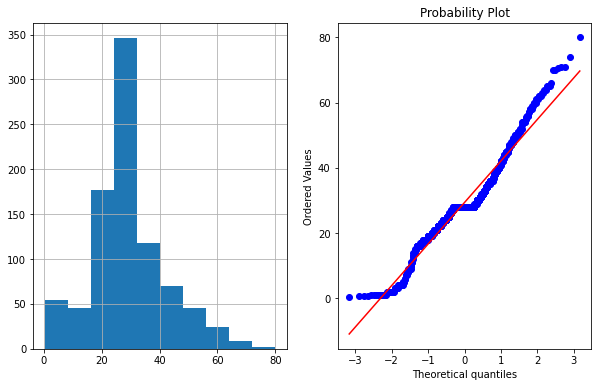

In [37]:
plot(data, 'Age')
# If age is falling in a straight line, we can see age is normally distributed or not.

### Logarithmic Distribution
* It's the way to transform the other distribution to normal distribution.

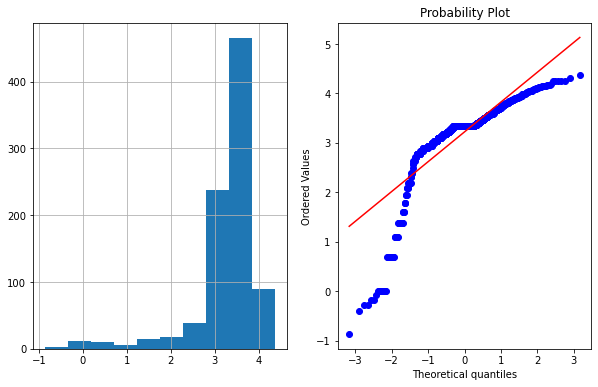

In [38]:
data['new_age'] = np.log(data['Age'])
plot(data, 'new_age')
# its not following the normal distribution

### Reciprocal Transformation
* It's nothing but reverse

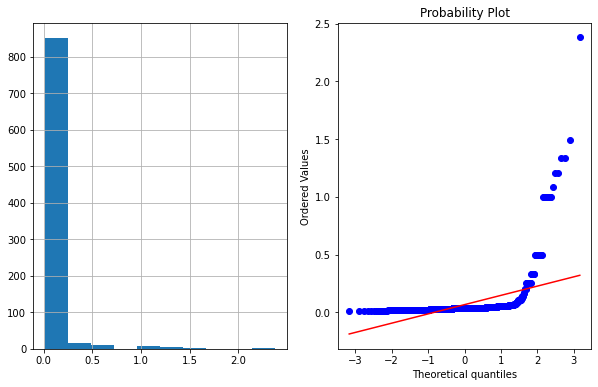

In [40]:
data['age_rec'] = 1/data.Age
plot(data, 'age_rec')
# its not following the normal distribution

### Square Root Transformation:


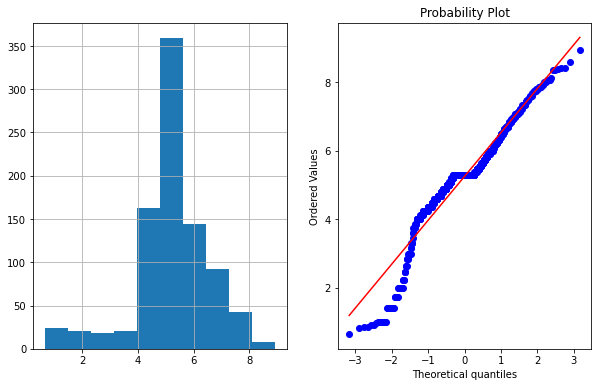

In [41]:
data['age_sq'] = data.Age**(1/2)
plot(data, 'age_sq')

### Exponential Transformation
* 

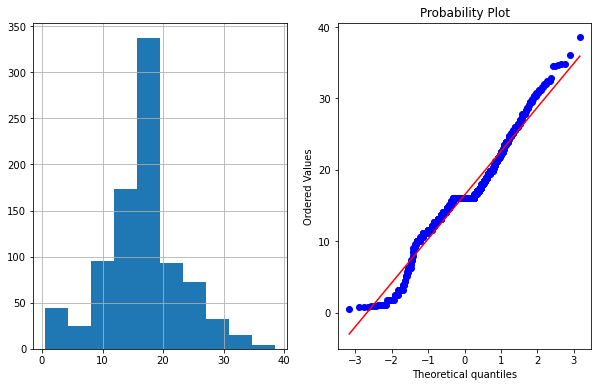

In [42]:
data['age_exp'] = data.Age**(1/1.2)
plot(data, 'age_exp')

### Box Cox Transformation

In [44]:
data['age_bc'], param = stat.boxcox(data.Age)

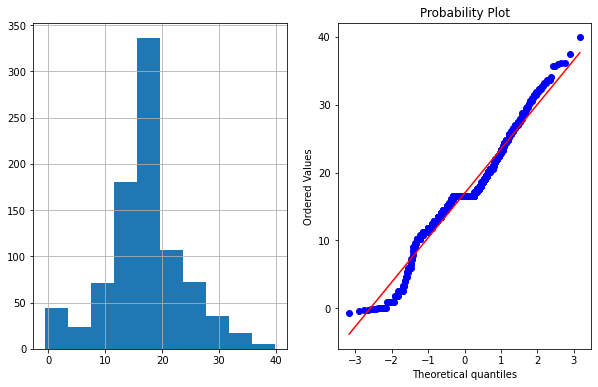

In [45]:
plot(data,'age_bc')

In [ ]:
* Like That we can try for many features and change the features into normal distribution. 
Becaoz normal distribution works well in distance calculating algorithms. 